# SVM on In Vivo Phototoxicity Dataset (Descriptors, Fingerprints, Homolumo and Combinations)


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, RDLogger, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, MACCSkeys
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.ML.Descriptors import MoleculeDescriptors as md

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    RandomizedSearchCV,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)

from sklearn.svm import SVC
import shap
import optuna

## Molecule, Descriptor + Fingerprints and Outlier Functions


In [20]:
def molecule_from_smiles(smiles):
    lg = RDLogger.logger()
    # Temporarily silence RDKit logs
    lg.setLevel(RDLogger.CRITICAL)
    try:
        # Extract molecule
        molecule = Chem.MolFromSmiles(smiles, sanitize=True)
        if molecule is None:
            return None, "failed"

        # Remove salts
        clean_molecule = rdMolStandardize.LargestFragmentChooser()
        molecule = clean_molecule.choose(molecule)

        # Sanitize molecule again to reflect changes
        Chem.SanitizeMol(molecule)
        return molecule, "succeed"
    except Exception as e:
        return None, f"error: {e}"
    finally:
        # Re-enable logging afterward
        lg.setLevel(RDLogger.INFO)


def calculate_descriptors(molecule):
    # Get all descriptors (1D/2D)
    descriptor_names = []
    for descriptor, _ in Descriptors._descList:
        descriptor_names.append(descriptor)

    # Use descriptors to calculate values
    calculator = md.MolecularDescriptorCalculator(descriptor_names)
    descriptor_values = calculator.CalcDescriptors(molecule)

    # Create dictionary
    descriptors = dict(zip(descriptor_names, descriptor_values))
    return descriptors


def compute_iqr_limits(df, factor=1.5):
    # Calculate IQR limits
    limits = {}
    for col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        # If IQR is 0 - column is too flat - skip
        if iqr == 0 or np.isnan(iqr):
            continue

        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        limits[col] = (lower, upper)
    return limits


def apply_iqr_limits(df, limits):
    # Apply the limits
    df_clipped = df.copy()
    for col, (lower, upper) in limits.items():
        df_clipped[col] = df_clipped[col].clip(lower, upper)
    return df_clipped


def bitvect_to_dict(fp, prefix):
    # Convert bit vector to dictionary (create features)
    n_bits = fp.GetNumBits()
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    features = {}
    for i, v in enumerate(arr):
        features[f"{prefix}_{i}"] = int(v)
    return features


def calculate_fingerprints(mol, bits=256):
    RDLogger.DisableLog("rdApp.*")
    # Calculate Morgan, RDKit, MACCS, AtomPair and Topological Torsion fingerprint
    feats = {}
    if mol is None:
        return feats

    # Morgan (ECFP) fingerprint
    morgan_bits = bits
    morgan_radius = 2
    fp_morgan = rdMolDescriptors.GetMorganFingerprintAsBitVect(
        mol, radius=morgan_radius, nBits=morgan_bits
    )
    feats.update(bitvect_to_dict(fp_morgan, f"Morgan{morgan_radius}_{morgan_bits}"))

    # RDKit topological fingerprint
    rdk_bits = bits
    fp_rdk = Chem.RDKFingerprint(mol, fpSize=rdk_bits)
    feats.update(bitvect_to_dict(fp_rdk, f"RDK_{rdk_bits}"))

    # MACCS keys (167 bits)
    fp_maccs = MACCSkeys.GenMACCSKeys(mol)
    feats.update(bitvect_to_dict(fp_maccs, "MACCS"))

    # AtomPair fingerprint
    ap_bits = bits
    fp_ap = rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(mol, nBits=ap_bits)
    feats.update(bitvect_to_dict(fp_ap, f"AtomPair_{ap_bits}"))

    # Topological torsion fingerprint
    tt_bits = bits
    fp_tt = rdMolDescriptors.GetHashedTopologicalTorsionFingerprintAsBitVect(
        mol, nBits=tt_bits
    )
    feats.update(bitvect_to_dict(fp_tt, f"Torsion_{tt_bits}"))

    RDLogger.EnableLog("rdApp.*")

    return feats


def prepare_3d_molecule(mol):
    # Create 3D molecule
    if mol is None:
        return None

    mol3d = Chem.AddHs(mol)

    try:
        # Calculate 3D coordinates and energy
        AllChem.EmbedMolecule(mol3d, AllChem.ETKDG())
        AllChem.UFFOptimizeMolecule(mol3d, maxIters=200)
    except Exception:
        return None

    return mol3d


def infer_charge_and_unpaired(mol):
    """
    Infer total charge and number of unpaired electrons from RDKit.
    Good enough for typical organic molecules.
    """
    total_charge = sum(a.GetFormalCharge() for a in mol.GetAtoms())
    n_unpaired = sum(a.GetNumRadicalElectrons() for a in mol.GetAtoms())
    return total_charge, n_unpaired


def compute_homo_lumo_xtb(mol):
    """
    Fast HOMO/LUMO computation using GFN2-xTB via morfeus.XTB.

    Returns the same keys as the old PySCF version:
        - HOMO_eV
        - LUMO_eV
        - HL_Gap_eV
    """
    import importlib
    import json
    import os
    import shutil
    import morfeus.xtb as morfeus_xtb

    feats = {
        "HOMO_eV": np.nan,
        "LUMO_eV": np.nan,
        "HL_Gap_eV": np.nan,
    }

    if mol is None:
        return feats

    # Ensure xtb binary is available before importing/reloading XTB internals
    if not shutil.which("xtb"):
        fallback_paths = ["/home/samuel/miniconda3/bin"]
        for p in fallback_paths:
            if os.path.exists(os.path.join(p, "xtb")):
                os.environ["PATH"] = p + os.pathsep + os.environ.get("PATH", "")
                break

    if not shutil.which("xtb"):
        return feats

    # Reload so morfeus re-evaluates executable availability in this session
    morfeus_xtb = importlib.reload(morfeus_xtb)

    def _parse_json_compat(self, json_file):
        with open(json_file, "r", encoding="utf8") as f:
            lines_without_error = [line for line in f if line.strip() != ","]
            json_fixed = "".join(lines_without_error)
            data = json.loads(json_fixed)

        self._results.charges = data.get("partial charges")

        # Different xtb versions may change this key name
        gap_val = data.get("HOMO-LUMO gap / eV")
        if gap_val is None:
            for key in data.keys():
                key_l = key.lower()
                if "homo" in key_l and "lumo" in key_l and "ev" in key_l:
                    gap_val = data[key]
                    break
        self._results.gap = float(gap_val) if gap_val is not None else np.nan

        self._results.total_energy = data.get("total energy")
        if data.get("dipole / a.u.") is not None:
            self._results.dipole_vect = np.array(data["dipole / a.u."])
        if self._method != "1" and data.get("atomic dipole moments") is not None:
            self._results.atom_dipole_vect = np.array(data["atomic dipole moments"])

    morfeus_xtb.XTB._parse_json = _parse_json_compat
    XTB_local = morfeus_xtb.XTB

    # Create 3D molecule (reuses your existing pipeline)
    mol3d = prepare_3d_molecule(mol)
    if mol3d is None:
        return feats

    # Extract elements and coordinates
    conf = mol3d.GetConformer()
    elements = []
    coords = []
    for atom in mol3d.GetAtoms():
        pos = conf.GetAtomPosition(atom.GetIdx())
        elements.append(atom.GetSymbol())
        coords.append([pos.x, pos.y, pos.z])
    coords = np.array(coords, dtype=float)  # Å

    charge, n_unpaired = infer_charge_and_unpaired(mol3d)

    try:
        # method=2 -> GFN2-xTB
        xtb_calc = XTB_local(
            elements=elements,
            coordinates=coords,
            method=2,
            charge=charge,
            n_unpaired=n_unpaired,
        )

        homo = float(xtb_calc.get_homo(unit="eV"))
        lumo = float(xtb_calc.get_lumo(unit="eV"))
        feats["HOMO_eV"] = homo
        feats["LUMO_eV"] = lumo
        feats["HL_Gap_eV"] = lumo - homo

    except Exception:
        # keep NaNs if xtb fails
        pass

    return feats

# Basic configuration


In [3]:
config_1 = {
    "similarity_threshold": 0.9,
    "correlation_threshold": 0.95,
    "test_size": 0.2,
    "random_state": 42,
    "fingerprint_size": 128,
    "kernel": "linear",
}

## Dataset Processing


In [21]:
# Configuration
from pathlib import Path


def process_datasets(
    dataset_root_name,
    original_datasets_location,
    fingerprint_size=128,
    similarity_threshold=0.9,
    correlation_threshold=0.95,
    test_size=0.2,
    random_state=42,
    excluded_descriptor_columns=None,
    drop_excluded_descriptors=True,
):
    notebook_dir = Path.cwd()
    if notebook_dir.name != "in_vivo_phototoxicity_lr_svm":
        notebook_dir = notebook_dir / "in_vivo_phototoxicity_lr_svm"

    dataset_dir = Path(original_datasets_location)
    if not dataset_dir.is_absolute():
        dataset_dir = (notebook_dir / dataset_dir).resolve()

    output_dir = notebook_dir / f"{dataset_root_name}_preprocessed"
    processed_dir = output_dir / "processed_datasets"
    prepared_dir = output_dir / "prepared_datasets"
    processed_dir.mkdir(parents=True, exist_ok=True)
    prepared_dir.mkdir(parents=True, exist_ok=True)

    ORIG_DATASET = dataset_dir / f"{dataset_root_name}_dataset.xlsx"
    SKIP_ROWS = 1
    SMILES_COL = "SMILES code"
    TARGET_COL = "Phototoxicity"
    FULL_OUTPUT_DATASET = processed_dir / f"{dataset_root_name}_homolumo_processed.xlsx"
    # Outputs
    TRAIN_X_CSV = prepared_dir / f"{dataset_root_name}_homolumo_x_train.csv"
    TEST_X_CSV = prepared_dir / f"{dataset_root_name}_homolumo_x_test.csv"
    TRAIN_Y_CSV = prepared_dir / f"{dataset_root_name}_homolumo_y_train.csv"
    TEST_Y_CSV = prepared_dir / f"{dataset_root_name}_homolumo_y_test.csv"

    if excluded_descriptor_columns is None:
        excluded_descriptor_columns = ["HOMO_eV", "LUMO_eV", "HL_Gap_eV"]

    excluded_columns_csv = (
        prepared_dir / f"excluded_descriptor_columns_{dataset_root_name}_homolumo.csv"
    )
    pd.Series(excluded_descriptor_columns).to_csv(excluded_columns_csv, index=False)
    print(f"Saved exclusion list to: {excluded_columns_csv}")

    # Load dataset and skip first row (Header)
    dataset = pd.read_excel(ORIG_DATASET, engine="openpyxl", skiprows=SKIP_ROWS)

    descriptor_rows = []
    fingerprint_rows = []  # fingerprints here
    state_molecules = []
    molecules = []

    for smiles in dataset[SMILES_COL].astype(str):
        molecule, state = molecule_from_smiles(smiles)
        state_molecules.append(state)
        molecules.append(molecule)

        if molecule is None:
            descriptor_rows.append({})
            fingerprint_rows.append({})
            continue

        # RDKit 1D/2D
        desc_feats = calculate_descriptors(molecule)

        # HOMO / LUMO / Gap via xTB
        homo_lumo_feats = compute_homo_lumo_xtb(molecule)

        # Merge descriptors + HOMO/LUMO
        all_feats = {**desc_feats, **homo_lumo_feats}
        descriptor_rows.append(all_feats)

        # Fingerprints (UNTOUCHED later)
        fp_feats = calculate_fingerprints(molecule, bits=fingerprint_size)
        fingerprint_rows.append(fp_feats)

    descriptor_data_all = pd.DataFrame(descriptor_rows)
    fingerprint_data_all = pd.DataFrame(fingerprint_rows)

    # Keep everything + status
    output = pd.concat(
        [
            dataset.reset_index(drop=True),
            descriptor_data_all.reset_index(drop=True),
            fingerprint_data_all.reset_index(drop=True),
        ],
        axis=1,
    )
    output["MoleculeStatus"] = state_molecules

    # Output whole dataset with descriptors and state
    with pd.ExcelWriter(FULL_OUTPUT_DATASET, engine="openpyxl") as writer:
        output.to_excel(writer, index=False, sheet_name="Descriptors")

    print(f"Output folder: {output_dir}")
    print(f"Full - Rows: {len(output)}/Columns: {output.shape[1]}")
    print(output.head().to_string(index=False))

    # Drop failed molecules - boolean array
    molecules_right = []
    for molecule in molecules:
        molecules_right.append(molecule is not None)

    if not any(molecules_right):
        raise ValueError("No valid molecules after SMILES parsing.")

    dataset_ok = dataset.loc[molecules_right].reset_index(drop=True)
    descriptor_ok = descriptor_data_all.loc[molecules_right].reset_index(drop=True)
    fingerprint_ok = fingerprint_data_all.loc[molecules_right].reset_index(drop=True)

    # Target
    y_full = dataset_ok[TARGET_COL].astype(int)

    # Take only numeric descriptor columns
    X_full = descriptor_ok.select_dtypes(include=[np.number]).copy()
    for column in X_full.columns:
        X_full[column] = X_full[column].replace([np.inf, -np.inf], np.nan)

    # Drop explicitly excluded descriptor columns (if requested)
    excluded_present = [c for c in excluded_descriptor_columns if c in X_full.columns]
    if drop_excluded_descriptors and excluded_present:
        X_full = X_full.drop(columns=excluded_present)
        print(f"Dropped excluded descriptor columns: {excluded_present}")
    elif not drop_excluded_descriptors and excluded_present:
        print(
            f"Excluded descriptor columns were found but kept in features: {excluded_present}"
        )

    # Drop columns that are entirely NaN
    all_nan_cols = X_full.columns[X_full.isna().all()].tolist()
    if all_nan_cols:
        print(f"Dropping {len(all_nan_cols)} NaN columns.")
        X_full = X_full.drop(columns=all_nan_cols)

    # Split dataset - train and test
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_full, test_size=test_size, random_state=random_state, stratify=y_full
    )

    # Calculate medians for each column in train only
    train_medians = X_train.median(numeric_only=True)

    # Fill missing values in both train and test using those medians
    n_train_nans_before = X_train.isna().sum().sum()
    n_test_nans_before = X_test.isna().sum().sum()

    X_train = X_train.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    n_train_nans_after = X_train.isna().sum().sum()
    n_test_nans_after = X_test.isna().sum().sum()
    print(f"Filled {n_train_nans_before - n_train_nans_after} NaNs in train set.")
    print(f"Filled {n_test_nans_before - n_test_nans_after} NaNs in test set.")

    # Compute constants on train only
    constant_cols = []
    for col in X_train.columns:
        top_freq = X_train[col].value_counts(normalize=True, dropna=False).max()
        if top_freq >= similarity_threshold:
            constant_cols.append(col)

    # Drop from train and apply same drop to test
    if constant_cols:
        X_train = X_train.drop(columns=constant_cols)
        X_test = X_test.drop(columns=constant_cols)
        print(f"Dropped {len(constant_cols)} constant/almost-constant columns.")

    # Compute absolute correlation matrix on training data
    corr_matrix = X_train.corr().abs()
    # Keep only upper triangle of the matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    # Find columns to drop - correlation
    high_corr_cols = []
    for col in upper.columns:
        if any(upper[col] > correlation_threshold):
            high_corr_cols.append(col)

    # Drop from both train and test
    if high_corr_cols:
        X_train = X_train.drop(columns=high_corr_cols)
        X_test = X_test.drop(columns=high_corr_cols)
        print(f"Dropped {len(high_corr_cols)} highly correlated columns.")

    # Compute IQR limits on training data
    iqr_limits = compute_iqr_limits(X_train, factor=1.5)

    # Apply limits to both train and test sets
    X_train = apply_iqr_limits(X_train, iqr_limits)
    X_test = apply_iqr_limits(X_test, iqr_limits)

    # Preserve column names and indices so we can reconstruct DataFrames after scaling
    train_cols = X_train.columns.tolist()
    train_index = X_train.index
    test_index = X_test.index

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train), columns=train_cols, index=train_index
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test), columns=train_cols, index=test_index
    )

    fps_full = fingerprint_ok.copy()
    fps_full.index = X_full.index

    fp_train = fps_full.loc[X_train_scaled.index]
    fp_test = fps_full.loc[X_test_scaled.index]

    # Remove constant fingerprints
    constant_fp_cols = []
    for col in fp_train.columns:
        top_freq = fp_train[col].value_counts(normalize=True, dropna=False).max()
        if top_freq == 1:  # fingerprints are binary, so 1 means constant 0/1 column
            constant_fp_cols.append(col)
    if constant_fp_cols:
        fp_train = fp_train.drop(columns=constant_fp_cols)
        fp_test = fp_test.drop(columns=constant_fp_cols)
        print(
            f"Dropped {len(constant_fp_cols)} constant/almost-constant fingerprint columns."
        )

    # Combine descriptors + fingerprints
    X_train_combined = pd.concat([X_train_scaled, fp_train], axis=1)
    X_test_combined = pd.concat([X_test_scaled, fp_test], axis=1)

    # Save processed datasets
    fp_cols = fingerprint_ok.columns.tolist()
    # pd.Series(fp_cols).to_csv("fp_columns.txt", index=False)
    desc_cols = [c for c in X_train_combined.columns if c not in fp_cols]
    pd.Series(desc_cols).to_csv(
        prepared_dir / f"desc_columns_{dataset_root_name}_homolumo.csv", index=False
    )

    X_train_scaled = X_train_combined
    X_test_scaled = X_test_combined

    X_train_scaled.to_csv(TRAIN_X_CSV, index=False)
    X_test_scaled.to_csv(TEST_X_CSV, index=False)
    y_train.to_csv(TRAIN_Y_CSV, index=False, header=[TARGET_COL])
    y_test.to_csv(TEST_Y_CSV, index=False, header=[TARGET_COL])

    print(f"Train - Rows: {len(X_train_scaled)}/Columns: {X_train_scaled.shape[1]}")
    print("First rows of train x:")
    print(X_train_scaled.head().to_string(index=False))
    print(f"Test - Rows: {len(X_test_scaled)}/Columns: {X_test_scaled.shape[1]}")
    print("First rows of train y:")
    print(y_train.head().to_string(index=False))
    X_train_scaled.describe()

    print("\nTrain set class counts:")
    print(y_train.value_counts())
    print("\nTrain set class ratio:")
    print(y_train.value_counts(normalize=True))

    print("\nTest set class counts:")
    print(y_test.value_counts())
    print("\nTest set class ratio:")
    print(y_test.value_counts(normalize=True))

    print(f"\nLength of descriptor columns: {len(desc_cols)}")
    print(f"Length of fingerprint columns: {len(fp_cols)}")

    return (
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        desc_cols,
        fp_cols,
    )


root_name = "in_vivo"
excluded_homo_lumo_columns = ["HOMO_eV", "LUMO_eV", "HL_Gap_eV"]
X_train, X_test, y_train, y_test, desc_cols, fp_cols = process_datasets(
    root_name,
    fingerprint_size=config_1["fingerprint_size"],
    similarity_threshold=config_1["similarity_threshold"],
    correlation_threshold=config_1["correlation_threshold"],
    test_size=config_1["test_size"],
    random_state=config_1["random_state"],
    original_datasets_location="../app/default_datasets",
    excluded_descriptor_columns=excluded_homo_lumo_columns,
    drop_excluded_descriptors=False,
)

Saved exclusion list to: /home/samuel/Desktop/7thSemester/Temp/ToxiPred/server-toxipred/in_vivo_phototoxicity_lr_svm/in_vivo_preprocessed/prepared_datasets/excluded_descriptor_columns_in_vivo_homolumo.csv
Output folder: /home/samuel/Desktop/7thSemester/Temp/ToxiPred/server-toxipred/in_vivo_phototoxicity_lr_svm/in_vivo_preprocessed
Full - Rows: 35/Columns: 908
                       Name                                                                                                                                         IUPAC name CAS registry number      Structure  Phototoxicity                                                                             SMILES code                                          Sources  Note  MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex      qed       SPS   MolWt  HeavyAtomMolWt  ExactMolWt  NumValenceElectrons  NumRadicalElectrons  MaxPartialCharge  MinPartialCharge  MaxAbsPartialCharge  MinAbsPartialCharge  FpDensityMorgan1  FpDens

In [5]:
display(X_train.head())

,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,NumValenceElectrons,MaxPartialCharge,MinPartialCharge,FpDensityMorgan1,...,Torsion_128_118,Torsion_128_119,Torsion_128_120,Torsion_128_121,Torsion_128_122,Torsion_128_123,Torsion_128_124,Torsion_128_125,Torsion_128_126,Torsion_128_127
23,0.131460,-0.630201,0.752237,0.695448,-0.964817,-1.101424,-0.998135,-0.588664,-0.651940,0.228684,...,0,0,1,1,1,0,1,1,1,0
19,-1.662881,0.251752,-1.622844,0.420027,-0.628343,-0.371286,-0.535710,1.230953,0.436729,0.176309,...,0,0,1,1,0,0,1,1,0,0
25,0.419614,-0.388110,0.375434,0.541690,0.112450,-0.266263,-0.073286,0.022065,1.833299,-1.188274,...,0,0,0,0,0,0,1,1,1,0
5,-1.662881,2.557177,1.672776,-0.898812,-0.787999,-1.612366,-1.576165,-1.820530,2.085469,-1.779317,...,0,0,1,1,1,0,1,1,1,0
34,-0.241887,0.921526,0.146973,0.296728,-0.384504,-0.627513,-0.709120,0.531357,-0.374737,0.398901,...,0,0,1,1,0,0,1,1,1,0


# Experiment Setup

Build feature sets for all requested SVM benchmarks:

- descriptors only
- descriptors + HOMO/LUMO
- descriptors + one fingerprint (one-by-one)
- descriptors + one fingerprint + HOMO/LUMO


In [22]:
# Shared experiment constants
RANDOM_STATE = 42
PRIMARY_METRIC = "roc_auc"
OPTUNA_TRIALS = 30
RANDOM_SEARCH_ITERS = 20

HOMO_LUMO_COLUMNS = ["HOMO_eV", "LUMO_eV", "HL_Gap_eV"]

# Descriptor subsets from the columns that are actually present in train/test data
desc_with_hl_cols = [
    c for c in desc_cols if c in X_train.columns and c in X_test.columns
]
desc_only_cols = [c for c in desc_with_hl_cols if c not in HOMO_LUMO_COLUMNS]
available_hl_cols = [c for c in HOMO_LUMO_COLUMNS if c in desc_with_hl_cols]

print(f"Descriptor columns (effective): {len(desc_with_hl_cols)}")
print(f"Descriptor columns without HOMO/LUMO: {len(desc_only_cols)}")
print(f"Available HOMO/LUMO columns: {available_hl_cols}")
if len(available_hl_cols) < len(HOMO_LUMO_COLUMNS):
    print(
        "Warning: not all HOMO/LUMO columns are available in current train/test data. "
        "Experiments requiring missing columns will be skipped."
    )

Descriptor columns (effective): 123
Descriptor columns without HOMO/LUMO: 120
Available HOMO/LUMO columns: ['HOMO_eV', 'LUMO_eV', 'HL_Gap_eV']


In [23]:
# Split fingerprint columns into one-by-one families from columns actually available
available_fp_cols = [c for c in X_train.columns if c in X_test.columns]
fingerprint_families = {
    "Morgan": [c for c in available_fp_cols if c.startswith("Morgan")],
    "RDKit": [c for c in available_fp_cols if c.startswith("RDK_")],
    "MACCS": [c for c in available_fp_cols if c.startswith("MACCS_")],
    "AtomPair": [c for c in available_fp_cols if c.startswith("AtomPair_")],
    "Torsion": [c for c in available_fp_cols if c.startswith("Torsion_")],
}

for family_name, family_cols in fingerprint_families.items():
    print(f"{family_name}: {len(family_cols)} available columns")

# Build requested feature sets and keep only those with true additional columns
feature_sets_requested = {
    "descriptors_only": desc_only_cols,
    "descriptors_plus_homolumo": desc_with_hl_cols,
}

for family_name, family_cols in fingerprint_families.items():
    feature_sets_requested[f"descriptors_plus_{family_name}"] = (
        desc_only_cols + family_cols
    )
    feature_sets_requested[f"descriptors_plus_{family_name}_plus_homolumo"] = (
        desc_with_hl_cols + family_cols
    )

feature_sets = {}
skipped_feature_sets = {}

for set_name, cols in feature_sets_requested.items():
    unique_cols = list(dict.fromkeys(cols))
    if set_name != "descriptors_only" and len(unique_cols) == len(desc_only_cols):
        skipped_feature_sets[set_name] = (
            "No additional available columns after preprocessing."
        )
        continue
    feature_sets[set_name] = unique_cols

print(f"Requested feature sets: {len(feature_sets_requested)}")
print(f"Runnable feature sets: {len(feature_sets)}")
if skipped_feature_sets:
    print("Skipped feature sets:")
    for k, v in skipped_feature_sets.items():
        print(f"- {k}: {v}")

Morgan: 123 available columns
RDKit: 94 available columns
MACCS: 121 available columns
AtomPair: 100 available columns
Torsion: 103 available columns
Requested feature sets: 12
Runnable feature sets: 12


In [24]:
# Build train/test matrices for each runnable feature set
dataset_splits = {}
for set_name, set_cols in feature_sets.items():
    # Keep only columns available in both train and test
    cols = [c for c in set_cols if c in X_train.columns and c in X_test.columns]
    if not cols:
        continue

    dataset_splits[set_name] = {
        "X_train": X_train[cols].copy(),
        "X_test": X_test[cols].copy(),
        "columns": cols,
    }

if not dataset_splits:
    raise ValueError(
        "No runnable feature set is available. Re-run preprocessing with available HOMO/LUMO and/or non-constant fingerprints."
    )

print("Prepared dataset splits:")
for set_name, split in dataset_splits.items():
    print(f"{set_name}: train={split['X_train'].shape}, test={split['X_test'].shape}")

Prepared dataset splits:
descriptors_only: train=(28, 120), test=(7, 120)
descriptors_plus_homolumo: train=(28, 123), test=(7, 123)
descriptors_plus_Morgan: train=(28, 243), test=(7, 243)
descriptors_plus_Morgan_plus_homolumo: train=(28, 246), test=(7, 246)
descriptors_plus_RDKit: train=(28, 214), test=(7, 214)
descriptors_plus_RDKit_plus_homolumo: train=(28, 217), test=(7, 217)
descriptors_plus_MACCS: train=(28, 241), test=(7, 241)
descriptors_plus_MACCS_plus_homolumo: train=(28, 244), test=(7, 244)
descriptors_plus_AtomPair: train=(28, 220), test=(7, 220)
descriptors_plus_AtomPair_plus_homolumo: train=(28, 223), test=(7, 223)
descriptors_plus_Torsion: train=(28, 223), test=(7, 223)
descriptors_plus_Torsion_plus_homolumo: train=(28, 226), test=(7, 226)


## SVM Tuning and Benchmarking

Two-stage tuning for each feature set:

1. Optuna broad search
2. RandomizedSearchCV refinement


[I 2026-04-10 01:43:04,834] A new study created in memory with name: no-name-9c454f4d-851c-4f2e-b48d-395d96b7fb3b


Running experiment: descriptors_only


[I 2026-04-10 01:43:06,147] Trial 0 finished with value: 0.6027777777777779 and parameters: {'k': 11, 'kernel': 'linear', 'C': 3.907967156822881, 'gamma': 'scale', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6027777777777779.
[I 2026-04-10 01:43:07,206] Trial 1 finished with value: 0.8444444444444444 and parameters: {'k': 15, 'kernel': 'linear', 'C': 659.871107205407, 'gamma': 'scale', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8444444444444444.
[I 2026-04-10 01:43:08,342] Trial 2 finished with value: 0.7638888888888888 and parameters: {'k': 10, 'kernel': 'linear', 'C': 0.055895242052179224, 'gamma': 'scale', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8444444444444444.
[I 2026-04-10 01:43:09,215] Trial 3 finished with value: 0.8 and parameters: {'k': 13, 'kernel': 'linear', 'C': 1.2173252504194043, 'gamma': 'scale', 'class_weight': None}. Best is trial 1 with value: 0.8444444444444444.
[I 2026-04-10 01:43:09,240] Trial 4 finished with valu

Optuna best CV AUC:  0.9222
Refined best CV AUC: 0.9222
Train AUC:           1.0000
Test AUC:            0.6667
Test F1:             0.6000
Input features:      120
Selected k:          18
Running experiment: descriptors_plus_homolumo


[I 2026-04-10 01:43:10,217] Trial 8 finished with value: 0.6194444444444446 and parameters: {'k': 10, 'kernel': 'linear', 'C': 65.04020246676569, 'gamma': 'auto', 'class_weight': None}. Best is trial 6 with value: 0.8555555555555555.
[I 2026-04-10 01:43:10,232] Trial 9 finished with value: 0.7305555555555555 and parameters: {'k': 5, 'kernel': 'linear', 'C': 23.66154006460317, 'gamma': 'scale', 'class_weight': None}. Best is trial 6 with value: 0.8555555555555555.
[I 2026-04-10 01:43:10,260] Trial 10 finished with value: 0.7388888888888888 and parameters: {'k': 20, 'kernel': 'rbf', 'C': 0.0011099001648454435, 'gamma': 'auto', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.8555555555555555.
[I 2026-04-10 01:43:10,287] Trial 11 finished with value: 0.9222222222222222 and parameters: {'k': 18, 'kernel': 'rbf', 'C': 831.1832707510931, 'gamma': 'scale', 'class_weight': 'balanced'}. Best is trial 11 with value: 0.9222222222222222.
[I 2026-04-10 01:43:10,314] Trial 12 finished with

...

Optuna best CV AUC:  0.7861
Refined best CV AUC: 0.7861
Train AUC:           0.9948
Test AUC:            0.2500
Test F1:             0.7273
Input features:      223
Selected k:          20
Running experiment: descriptors_plus_Torsion_plus_homolumo


[I 2026-04-10 01:43:20,202] Trial 8 finished with value: 0.5805555555555555 and parameters: {'k': 10, 'kernel': 'linear', 'C': 65.04020246676569, 'gamma': 'auto', 'class_weight': None}. Best is trial 6 with value: 0.7138888888888889.
[I 2026-04-10 01:43:20,227] Trial 9 finished with value: 0.5583333333333333 and parameters: {'k': 5, 'kernel': 'linear', 'C': 23.66154006460317, 'gamma': 'scale', 'class_weight': None}. Best is trial 6 with value: 0.7138888888888889.
[I 2026-04-10 01:43:20,268] Trial 10 finished with value: 0.7638888888888888 and parameters: {'k': 20, 'kernel': 'rbf', 'C': 0.0011099001648454435, 'gamma': 'auto', 'class_weight': 'balanced'}. Best is trial 10 with value: 0.7638888888888888.
[I 2026-04-10 01:43:20,301] Trial 11 finished with value: 0.7638888888888888 and parameters: {'k': 21, 'kernel': 'rbf', 'C': 0.0017737525834891155, 'gamma': 'auto', 'class_weight': 'balanced'}. Best is trial 10 with value: 0.7638888888888888.
[I 2026-04-10 01:43:20,330] Trial 12 finished 

Optuna best CV AUC:  0.7861
Refined best CV AUC: 0.7861
Train AUC:           0.9948
Test AUC:            0.2500
Test F1:             0.7273
Input features:      226
Selected k:          20

Final Ranking (sorted by test ROC-AUC):


,feature_set,n_input_features,selected_k,cv_splits,optuna_cv_auc,refine_cv_auc,train_auc,test_auc,train_f1,test_f1,test_accuracy
0,descriptors_only,120,18,5,0.922222,0.922222,1.000000,0.666667,1.000000,0.600000,0.428571
1,descriptors_plus_homolumo,123,18,5,0.922222,0.922222,1.000000,0.666667,1.000000,0.600000,0.428571
2,descriptors_plus_RDKit,214,18,5,0.922222,0.922222,1.000000,0.666667,1.000000,0.600000,0.428571
3,descriptors_plus_RDKit_plus_homolumo,217,18,5,0.922222,0.922222,1.000000,0.666667,1.000000,0.600000,0.428571
4,descriptors_plus_MACCS,241,8,5,0.941667,0.891667,0.968750,0.583333,0.903226,0.333333,0.428571
5,descriptors_plus_MACCS_plus_homolumo,244,8,5,0.941667,0.891667,0.968750,0.583333,0.903226,0.333333,0.428571
6,descriptors_plus_Morgan,243,21,5,0.875000,0.875000,1.000000,0.333333,1.000000,0.444444,0.285714
7,descriptors_plus_Morgan_plus_homolumo,246,21,5,0.875000,0.875000,1.000000,0.333333,1.000000,0.444444,0.285714
8,descriptors_plus_AtomPair,220,21,5,0.855556,0.855556,1.000000,0.333333,1.000000,0.600000,0.428571
9,descriptors_plus_AtomPair_plus_homolumo,223,21,5,0.855556,0.855556,1.000000,0.333333,1.000000,0.600000,0.428571



Winner:
1) descriptors_only
2) descriptors_plus_homolumo


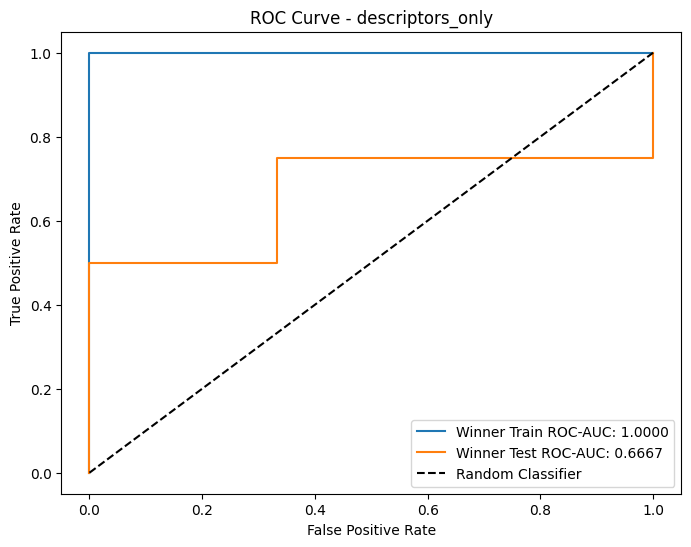


Winner confusion matrices:
Train:
[[12  0]
 [ 0 16]]
Test:
[[0 3]
 [1 3]]


In [25]:
import warnings
from collections import OrderedDict

from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.base import clone

warnings.filterwarnings("ignore")


def make_adaptive_cv(y, preferred_splits=5, random_state=42):
    class_counts = y.value_counts()
    min_class_count = int(class_counts.min())
    n_splits = min(preferred_splits, min_class_count)
    if n_splits < 2:
        raise ValueError(
            "Not enough samples in the minority class for stratified CV (need at least 2)."
        )
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)


def _safe_roc_auc(y_true, y_prob):
    unique_classes = np.unique(y_true)
    if len(unique_classes) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


def _build_pipeline(k, C, kernel, gamma, class_weight):
    if kernel == "linear":
        gamma_value = "scale"  # ignored by linear kernel
    else:
        gamma_value = gamma

    return Pipeline(
        [
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=k)),
            (
                "svc",
                SVC(
                    C=C,
                    kernel=kernel,
                    gamma=gamma_value,
                    class_weight=class_weight,
                    probability=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def _expand_log_candidates(center_value, min_value=1e-4, max_value=1e4):
    center_value = float(center_value)
    base = np.log10(max(center_value, min_value))
    candidates = [
        10 ** (base - 1.0),
        10 ** (base - 0.5),
        10**base,
        10 ** (base + 0.5),
        10 ** (base + 1.0),
    ]
    candidates = [float(np.clip(v, min_value, max_value)) for v in candidates]
    return sorted(set(candidates))


def evaluate_split(model, X_train_part, X_test_part, y_train_part, y_test_part):
    y_train_pred = model.predict(X_train_part)
    y_test_pred = model.predict(X_test_part)

    y_train_prob = model.predict_proba(X_train_part)[:, 1]
    y_test_prob = model.predict_proba(X_test_part)[:, 1]

    metrics = {
        "train_accuracy": accuracy_score(y_train_part, y_train_pred),
        "train_precision": precision_score(y_train_part, y_train_pred, zero_division=0),
        "train_recall": recall_score(y_train_part, y_train_pred, zero_division=0),
        "train_f1": f1_score(y_train_part, y_train_pred, zero_division=0),
        "train_auc": _safe_roc_auc(y_train_part, y_train_prob),
        "test_accuracy": accuracy_score(y_test_part, y_test_pred),
        "test_precision": precision_score(y_test_part, y_test_pred, zero_division=0),
        "test_recall": recall_score(y_test_part, y_test_pred, zero_division=0),
        "test_f1": f1_score(y_test_part, y_test_pred, zero_division=0),
        "test_auc": _safe_roc_auc(y_test_part, y_test_prob),
        "train_cm": confusion_matrix(y_train_part, y_train_pred),
        "test_cm": confusion_matrix(y_test_part, y_test_pred),
        "y_train_prob": y_train_prob,
        "y_test_prob": y_test_prob,
    }
    return metrics


def tune_one_feature_set(set_name, X_train_part, y_train_part, preferred_splits=5):
    cv = make_adaptive_cv(
        y_train_part, preferred_splits=preferred_splits, random_state=RANDOM_STATE
    )

    n_features = X_train_part.shape[1]
    n_train = X_train_part.shape[0]
    max_k = min(n_features, max(5, int(0.8 * n_train)))
    min_k = min(5, max_k)

    def objective(trial):
        k = trial.suggest_int("k", min_k, max_k)
        kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
        C = trial.suggest_float("C", 1e-3, 1e3, log=True)
        gamma = trial.suggest_categorical("gamma", ["scale", "auto"])
        class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

        pipe = _build_pipeline(
            k=k,
            C=C,
            kernel=kernel,
            gamma=gamma,
            class_weight=class_weight,
        )
        scores = cross_val_score(
            pipe,
            X_train_part,
            y_train_part,
            scoring=PRIMARY_METRIC,
            cv=cv,
            n_jobs=-1,
        )
        return float(np.nanmean(scores))

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)

    optuna_best = study.best_params.copy()

    # RandomizedSearchCV refinement around Optuna best params
    c_candidates = _expand_log_candidates(
        optuna_best["C"], min_value=1e-4, max_value=1e4
    )
    k_candidates = sorted(
        set(
            [
                min_k,
                max_k,
                int(np.clip(optuna_best["k"], min_k, max_k)),
                int(np.clip(optuna_best["k"] - 2, min_k, max_k)),
                int(np.clip(optuna_best["k"] + 2, min_k, max_k)),
            ]
        )
    )

    if optuna_best["kernel"] == "linear":
        gamma_candidates = ["scale"]
    else:
        gamma_candidates = [optuna_best["gamma"], "scale", "auto"]

    base_pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=min_k)),
            (
                "svc",
                SVC(
                    probability=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    param_distributions = {
        "select__k": k_candidates,
        "svc__C": c_candidates,
        "svc__kernel": [optuna_best["kernel"]],
        "svc__gamma": gamma_candidates,
        "svc__class_weight": [optuna_best["class_weight"], None, "balanced"],
    }

    random_search = RandomizedSearchCV(
        estimator=base_pipe,
        param_distributions=param_distributions,
        n_iter=min(
            RANDOM_SEARCH_ITERS,
            len(k_candidates) * len(c_candidates) * len(gamma_candidates) * 3,
        ),
        scoring=PRIMARY_METRIC,
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )
    random_search.fit(X_train_part, y_train_part)

    tuned_model = random_search.best_estimator_
    selected_mask = tuned_model.named_steps["select"].get_support()
    selected_features = X_train_part.columns[selected_mask].tolist()

    return {
        "study": study,
        "optuna_best_params": optuna_best,
        "optuna_best_score": float(study.best_value),
        "random_search": random_search,
        "refine_best_params": random_search.best_params_,
        "refine_best_score": float(random_search.best_score_),
        "model": tuned_model,
        "selected_features": selected_features,
        "selected_k": int(tuned_model.named_steps["select"].k),
        "cv_splits": cv.get_n_splits(),
        "n_features_in": n_features,
    }


results_rows = []
experiment_details = OrderedDict()

for set_name, split in dataset_splits.items():
    print("=" * 100)
    print(f"Running experiment: {set_name}")
    X_train_part = split["X_train"]
    X_test_part = split["X_test"]

    tuned = tune_one_feature_set(
        set_name=set_name,
        X_train_part=X_train_part,
        y_train_part=y_train,
        preferred_splits=5,
    )

    final_model = tuned["model"]
    fit_model = clone(final_model)
    fit_model.fit(X_train_part, y_train)

    metrics = evaluate_split(fit_model, X_train_part, X_test_part, y_train, y_test)

    row = {
        "feature_set": set_name,
        "n_input_features": tuned["n_features_in"],
        "selected_k": tuned["selected_k"],
        "cv_splits": tuned["cv_splits"],
        "optuna_cv_auc": tuned["optuna_best_score"],
        "refine_cv_auc": tuned["refine_best_score"],
        "train_auc": metrics["train_auc"],
        "test_auc": metrics["test_auc"],
        "train_f1": metrics["train_f1"],
        "test_f1": metrics["test_f1"],
        "train_accuracy": metrics["train_accuracy"],
        "test_accuracy": metrics["test_accuracy"],
        "train_precision": metrics["train_precision"],
        "test_precision": metrics["test_precision"],
        "train_recall": metrics["train_recall"],
        "test_recall": metrics["test_recall"],
        "optuna_best_params": tuned["optuna_best_params"],
        "refine_best_params": tuned["refine_best_params"],
        "selected_features": tuned["selected_features"],
    }
    results_rows.append(row)

    experiment_details[set_name] = {
        "model": fit_model,
        "metrics": metrics,
        "tuning": tuned,
        "columns": split["columns"],
    }

    print(f"Optuna best CV AUC:  {tuned['optuna_best_score']:.4f}")
    print(f"Refined best CV AUC: {tuned['refine_best_score']:.4f}")
    print(f"Train AUC:           {metrics['train_auc']:.4f}")
    print(f"Test AUC:            {metrics['test_auc']:.4f}")
    print(f"Test F1:             {metrics['test_f1']:.4f}")
    print(f"Input features:      {tuned['n_features_in']}")
    print(f"Selected k:          {tuned['selected_k']}")

results_df = (
    pd.DataFrame(results_rows)
    .sort_values(by=["test_auc", "refine_cv_auc", "test_f1"], ascending=False)
    .reset_index(drop=True)
)

print("\nFinal Ranking (sorted by test ROC-AUC):")
display(
    results_df[
        [
            "feature_set",
            "n_input_features",
            "selected_k",
            "cv_splits",
            "optuna_cv_auc",
            "refine_cv_auc",
            "train_auc",
            "test_auc",
            "train_f1",
            "test_f1",
            "test_accuracy",
        ]
    ]
)

winner_name = results_df.loc[0, "feature_set"]
runner_up_name = results_df.loc[1, "feature_set"] if len(results_df) > 1 else None

print("\nWinner:")
print(f"1) {winner_name}")
if runner_up_name is not None:
    print(f"2) {runner_up_name}")

# Plot ROC curves for winner (train + test)
winner = experiment_details[winner_name]
winner_metrics = winner["metrics"]

fpr_train, tpr_train, _ = roc_curve(y_train, winner_metrics["y_train_prob"])
fpr_test, tpr_test, _ = roc_curve(y_test, winner_metrics["y_test_prob"])

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_train,
    tpr_train,
    label=f"Winner Train ROC-AUC: {winner_metrics['train_auc']:.4f}",
)
plt.plot(
    fpr_test,
    tpr_test,
    label=f"Winner Test ROC-AUC: {winner_metrics['test_auc']:.4f}",
)
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {winner_name}")
plt.legend()
plt.show()

print("\nWinner confusion matrices:")
print("Train:")
print(winner_metrics["train_cm"])
print("Test:")
print(winner_metrics["test_cm"])